In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, project_root)

import numpy as np
from src.poisson_hypergraph import GH
from src.simulated_annealing import SimulatedAnnealingApprox
import xgi
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm
import math


def p_e_given_f(g, theta, labels, e_index, f_index):
    e = g.get_edges()[e_index]
    f = g.get_edges()[f_index]

    node_labels = labels
    prev_nodes = list(range(g.last_added[e_index - 1] + 1))
    p, q, gamma_nu, gamma_nr, gamma_eu, gamma_er = theta

    # novel nodes counting
    novel_nodes = set(e) - set(prev_nodes)
    novel_labels = [node_labels[node] for node in novel_nodes]
    nov1 = sum(novel_labels)
    nov0 = len(novel_labels) - nov1

    # external nodes counting
    external_nodes = set(prev_nodes) - set(f)
    external_node_labels = [node_labels[node] for node in external_nodes]  

    external_nodes_added = external_nodes.intersection(e)
    external_nodes_added_labels = [node_labels[node] for node in external_nodes_added] 

    ext1 = sum(external_nodes_added_labels)
    ext0 = len(external_nodes_added_labels) - ext1

    posext1 = sum(external_node_labels)
    posext0 = len(external_node_labels) - posext1

    # copied and not copied nodes counting
    copied_nodes = e.intersection(f)
    copied_nodes_labels = [node_labels[node] for node in copied_nodes]

    cop1 = sum(copied_nodes_labels)
    cop0 = len(copied_nodes_labels) - cop1

    not_copied_nodes = set(f) - set(e)
    not_copied_nodes_labels = [node_labels[node] for node in not_copied_nodes]

    notcop1 = sum(not_copied_nodes_labels)
    notcop0 = len(not_copied_nodes_labels) - notcop1

    # find probs of u being label 1 and 0
    f_labels = [node_labels[node] for node in f]
    prob_u_label_equals_1 = sum(f_labels) / len(f_labels)
    prob_u_label_equals_0 = 1 - prob_u_label_equals_1

    # calculate prob of e given f and u_label = 1
    prob_given_f_u_label_1 = (p**(cop1-1)) * ((1-p)**notcop1) * (q**cop0) * ((1-q)**notcop0)
    prob_given_f_u_label_1 *= (gamma_eu**ext1) * math.exp(-gamma_eu) / math.factorial(ext1) / math.comb(posext1, ext1)
    prob_given_f_u_label_1 *= (gamma_er**ext0) * math.exp(-gamma_er) / math.factorial(ext0) / math.comb(posext0, ext0)
    prob_given_f_u_label_1 *= (gamma_nu**nov1) * math.exp(-gamma_nu) / math.factorial(nov1)
    prob_given_f_u_label_1 *= (gamma_nr**nov0) * math.exp(-gamma_nr) / math.factorial(nov0)

    # calculate prob of e given f and u_label = 0
    prob_given_f_u_label_0 = (p**(cop0-1)) * ((1-p)**notcop0) * (q**cop1) * ((1-q)**notcop1)
    prob_given_f_u_label_0 *= (gamma_eu**ext0) * math.exp(-gamma_eu) / math.factorial(ext0) / math.comb(posext0, ext0)
    prob_given_f_u_label_0 *= (gamma_er**ext1) * math.exp(-gamma_er) / math.factorial(ext1) / math.comb(posext1, ext1)
    prob_given_f_u_label_0 *= (gamma_nu**nov0) * math.exp(-gamma_nu) / math.factorial(nov0)
    prob_given_f_u_label_0 *= (gamma_nr**nov1) * math.exp(-gamma_nr) / math.factorial(nov1)

    # put together, return full expression
    return prob_u_label_equals_1*prob_given_f_u_label_1 + prob_u_label_equals_0*prob_given_f_u_label_0
    

def generate_canidate_f_approx(g, e_index):
    e = g.get_edges()[e_index]
    k = 0
    canidate_f_indexes = []
    for f_index in range(e_index):
        f = g.get_edges()[f_index]
        inter_size = len(e.intersection(f))

        if inter_size == k:
            canidate_f_indexes.append(f_index)
        elif inter_size > k:
            k = inter_size
            canidate_f_indexes = [f_index]
    
    return canidate_f_indexes

def total_log_likelihood_approx_baseline(g, theta, labels):
    # e_index 0 must be given...

    summation = 0
    for e_index in range(1, len(g.get_edges())):
        # add all edges together
        e_sum = 0
        canidate_f_indexes = g.generate_canidate_f_approx(e_index)
        for f_index in canidate_f_indexes:
            e_sum += g.p_e_given_f(theta, labels, e_index, f_index)
        
        e_sum /= len(canidate_f_indexes) # divide by possible f_choices
        summation += np.log(e_sum)

    return summation

/home/fcataldo/labeled-hypercopy/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [2]:
import time

true_p = .9
true_q = .1
gamma_nu, gamma_nr, gamma_eu, gamma_er = .5, .1, 1, 0.25
timesteps = 100
true_theta = [true_p, true_q, gamma_nu, gamma_nr, gamma_eu, gamma_er]

def generate_graph_26_starting_nodes(true_theta, timesteps):
    true_p, true_q, gamma_nu, gamma_nr, gamma_eu, gamma_er = true_theta
    H = xgi.Hypergraph([[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25]])
    H.set_node_attributes({0:0,1:0,2:0,3:0,4:0,5:0,6:0,7:0,8:0,9:0,10:0,11:0,12:0,13:1,14:1,15:1,16:1,17:1,18:1,19:1,20:1,21:1,22:1,23:1,24:1,25:1}, name="label")
    g=GH(H, [0,1], true_p, true_q)
    g.add_hyperedge(timesteps, gamma_nu, gamma_nr, gamma_eu, gamma_er)

    return g

g = generate_graph_26_starting_nodes(true_theta, timesteps)

start_time = time.perf_counter()
for _ in range(1000):
    baseline_LL = total_log_likelihood_approx_baseline(g, true_theta, g.get_labels())
end_time = time.perf_counter()

baseline_LL_time = end_time - start_time


start_time = time.perf_counter()
for _ in range(1000):
    new_LL = g.total_log_likelihood_approx(true_theta, g.get_labels())
end_time = time.perf_counter()

new_LL_time = end_time - start_time

print("baseline LL time: " + str(baseline_LL_time))
print("new LL time: " + str(new_LL_time))

still_working = np.isclose(baseline_LL, new_LL)
print("np isclose: " + str(still_working))
print("baseline LL = " + str(baseline_LL))
print("new_LL: " + str(new_LL))


baseline LL time: 6.66010413505137
new LL time: 3.9477329403162003
np isclose: True
baseline LL = -1125.1870586072562
new_LL: -1125.1870586072562


In [3]:
# check against violet...
# think about a way to implement with multiplication... its not addition
summation = 0
for e_index in range(1, len(g.get_edges())):
    e_sum = 0
    for f_index in range(e_index):
        f = g.get_edges()[f_index]
        e = g.get_edges()[e_index]
        intersect = len(f.intersection(e))
        f_sum = 0
        if (intersect != 0):
            for u_index in g.get_edges()[f_index]:
                f_sum += g.likelihood_given_u_f(f_index, u_index, e_index, true_theta) / intersect
                # print(g.likelihood_given_u_f(f_index, u_index, e_index, true_theta))
        e_sum += f_sum
    e_sum /= e_index
    summation += np.log(e_sum)

print(summation)


new_LL = g.total_log_likelihood_complete(true_theta, g.get_labels())
print(new_LL)

print(summation-new_LL)



-1393.0402038960194
-1393.0402038960194
0.0


In [4]:
# Check simulated annealing class likelihood calulation

sa = SimulatedAnnealingApprox(g, true_theta)

print(sa.calculate_likelihood_with_f_e_pairs(g.get_labels()))

print(g.total_log_likelihood_approx(true_theta, g.get_labels()))

start_time = time.perf_counter()
for _ in range(1000):
    baseline_LL = g.total_log_likelihood_approx(true_theta, g.get_labels())
end_time = time.perf_counter()

baseline_LL_time = end_time - start_time


start_time = time.perf_counter()
for _ in range(1000):
    new_LL = sa.calculate_likelihood_with_f_e_pairs(g.get_labels())
end_time = time.perf_counter()

new_LL_time = end_time - start_time

print("old approx LL time: " + str(baseline_LL_time))
print("new approx LL time: " + str(new_LL_time))

still_working = np.isclose(baseline_LL, new_LL)
print("np isclose: " + str(still_working))
print("old approx LL = " + str(baseline_LL))
print("new approx LL = " + str(new_LL))

-1354.653785076762
-1125.1870586072562
old approx LL time: 3.9467583131045103
new approx LL time: 10.713475888594985
np isclose: False
old approx LL = -1125.1870586072562
new approx LL = -1354.653785076762


In [5]:
# test greedy calculate prob


true_p = .9
true_q = .1
gamma_nu, gamma_nr, gamma_eu, gamma_er = 1, .25, 1, .25
true_theta = [true_p, true_q, gamma_nu, gamma_nr, gamma_eu, gamma_er]

g = generate_graph_26_starting_nodes(true_theta, 100)
sa = SimulatedAnnealingApprox(g, true_theta)

labels = sa.labels
labels_changed = labels.copy()

new_LL = None
baseline_LL = None

changed_index = np.random.choice(range(len(labels_changed)))
labels_changed[changed_index] = 1 - labels_changed[changed_index]

start_time = time.perf_counter()
for _ in range(1000):
    baseline_LL = sa.calculate_likelihood_with_f_e_pairs(labels_changed)
end_time = time.perf_counter()

baseline_LL_time = end_time - start_time


start_time = time.perf_counter()
for _ in range(1000):
    
    new_LL = sa.calculate_likelihood_with_f_e_pairs_greedy(changed_index, labels_changed[changed_index])
end_time = time.perf_counter()

new_LL_time = end_time - start_time

print("old approx LL time: " + str(baseline_LL_time))
print("new approx LL time: " + str(new_LL_time))

still_working = np.isclose(baseline_LL, new_LL)
print("np isclose: " + str(still_working))
print("old approx LL = " + str(baseline_LL))
print("new approx LL = " + str(new_LL))

print(new_LL / baseline_LL)

old approx LL time: 47.80877998843789
new approx LL time: 2.503842271864414
np isclose: True
old approx LL = -3026.617802715753
new approx LL = -3026.617802715753
1.0


In [6]:
# test greedy prob change with multiple updates

true_p = .9
true_q = .1
gamma_nu, gamma_nr, gamma_eu, gamma_er = 1, .25, 1, .25
true_theta = [true_p, true_q, gamma_nu, gamma_nr, gamma_eu, gamma_er]

g = generate_graph_26_starting_nodes(true_theta, 50)
sa = SimulatedAnnealingApprox(g, true_theta)

labels = sa.labels
labels_changed = labels.copy()

changed_indexes = np.random.choice(range(len(labels_changed)), 5)
for index in changed_indexes:
    labels_changed[index] = 1 - labels_changed[index]

start_time = time.perf_counter()
for _ in range(10):
    sa.step_not_greedy()
end_time = time.perf_counter()

baseline_LL_time = end_time - start_time


start_time = time.perf_counter()
for _ in range(10):
    sa.step()
end_time = time.perf_counter()

new_LL_time = end_time - start_time

print("old approx LL time: " + str(baseline_LL_time))
print("new approx LL time: " + str(new_LL_time))

# still_working = np.isclose(baseline_LL, new_LL)
# print("np isclose: " + str(still_working))
print("old approx LL = " + str(baseline_LL))
print("new approx LL = " + str(new_LL))

print(sa.likelihoods_per_step)

old approx LL time: 0.22666185535490513
new approx LL time: 0.037703124806284904
old approx LL = -3026.617802715753
new approx LL = -3026.617802715753
[np.float64(-1051.2765038978487), np.float64(-1092.5456462959062), np.float64(-1092.0109225388921), np.float64(-1050.5057856989326), np.float64(-1062.1388113217238), np.float64(-1059.3485488499914), np.float64(-1051.6682163734667), np.float64(-1047.2055683096748), np.float64(-1091.235756954635), np.float64(-1128.9803094081499), np.float64(-1128.2348841563498), np.float64(-1126.1699316160416), np.float64(-1123.0560167176088), np.float64(-1149.5989227933815), np.float64(-1151.2320298670963), np.float64(-1155.8452408198493), np.float64(-1152.5455078818802), np.float64(-1112.548506281183), np.float64(-1109.450630839475), np.float64(-1159.7594653971635), np.float64(-1197.765344658601)]


15.708262880459495
-696.2219433093786
0.2247110120603361


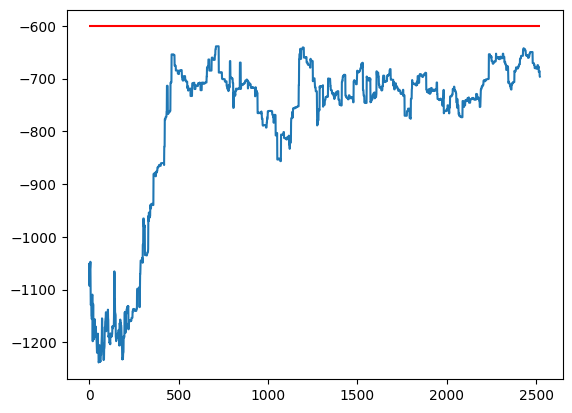

In [ ]:
import matplotlib.pyplot as plt

for _ in range(20*50):
    sa.step()

plt.plot(range(len(sa.likelihoods_per_step)), sa.likelihoods_per_step)
plt.hlines(y=g.total_log_likelihood_approx(true_theta, g.get_labels()), xmin=0, xmax=len(sa.likelihoods_per_step), color="red")

print(sa.likelihoods_per_step[-1])
print(sa.aris_per_step[-1])